2. Notebook 

In [27]:
# =============================================================================
# Projeto: Deteção de Intrusões em Tráfego de Rede (IDS)
# Dataset: CIC-IDS-2017
# Alunos: [Nomes do Grupo]
# Disciplina: Aprendizagem Automática para Cibersegurança
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)

print("="*80)
print("PROJETO DE APRENDIZAGEM AUTOMÁTICA PARA CIBERSEGURANÇA")
print("Deteção de Intrusões em Tráfego de Rede - CIC-IDS-2017")
print("="*80)

PROJETO DE APRENDIZAGEM AUTOMÁTICA PARA CIBERSEGURANÇA
Deteção de Intrusões em Tráfego de Rede - CIC-IDS-2017


2.1 Carregamento e Combinação dos Dados

In [ ]:
# =============================================================================
# 1. CARREGAMENTO E COMBINAÇÃO DOS DATASETS
# =============================================================================
# Nota: O dataset CIC-IDS-2017 está dividido em vários ficheiros CSV correspondentes
# a diferentes dias da semana. Vamos carregá-los todos e combiná-los.

import os
from glob import glob

# Caminho para a pasta com os ficheiros CSV
# Ajustar conforme necessário
data_path = "C:\Users\Admin\Documents\Universidade\3º Ano\Aprendizagem Automática em CIbersegurança\MachineLearningCVE"

# Procurar todos os ficheiros CSV
csv_files = glob(os.path.join(data_path, "*.csv"))
print(f"Ficheiros CSV encontrados: {len(csv_files)}")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

# Carregar e combinar todos os datasets
def load_and_combine_datasets(file_list):
    """Carrega múltiplos CSV e combina num único DataFrame"""
    all_dfs = []
    for file in file_list:
        print(f"Carregando {os.path.basename(file)}...")
        try:
            # Tentar carregar com encoding='latin1' devido a caracteres especiais
            df = pd.read_csv(file, encoding='latin1', low_memory=False)
            print(f"  Shape: {df.shape}")
            all_dfs.append(df)
        except Exception as e:
            print(f"  Erro ao carregar: {e}")
    
    # Combinar todos os DataFrames
    combined_df = pd.concat(all_dfs, ignore_index=True)
    return combined_df

# Carregar e combinar (pode demorar ~2-3 minutos)
print("\nCarregando e combinando datasets...")
df = load_and_combine_datasets(csv_files)
print(f"\nDataset combinado: {df.shape[0]} linhas, {df.shape[1]} colunas")

# Visualizar primeiras linhas
print("\nPrimeiras 5 linhas do dataset:")
df.head()

Ficheiros CSV encontrados: 8
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Monday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv

Carregando e combinando datasets...
Carregando Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
  Shape: (225745, 79)
Carregando Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
  Shape: (286467, 79)
Carregando Friday-WorkingHours-Morning.pcap_ISCX.csv...
  Shape: (191033, 79)
Carregando Monday-WorkingHours.pcap_ISCX.csv...
  Shape: (529918, 79)
Carregando Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
  Shape: (288602, 79)
Carregando Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
  Shape: (170366, 79)
Carregando Tuesday-WorkingHo

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


2.2 Análise Exploratória e Pré-processamento


2.1 INFORMAÇÕES GERAIS DO DATASET

Tipos de dados das colunas:
int64      54
float64    24
object      1
Name: count, dtype: int64

Valores nulos por coluna:
Colunas com valores nulos: 1
Flow Bytes/s    1358
dtype: int64

2.2 IDENTIFICAÇÃO DA COLUNA DE LABELS
Colunas que podem ser a label: [' Label']

Coluna de label identificada: ' Label'
Valores únicos na coluna: ['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack ï¿½ Brute Force' 'Web Attack ï¿½ XSS'
 'Web Attack ï¿½ Sql Injection' 'FTP-Patator' 'SSH-Patator'
 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']

2.3 DISTRIBUIÇÃO DAS CLASSES

Distribuição original:
 Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttp

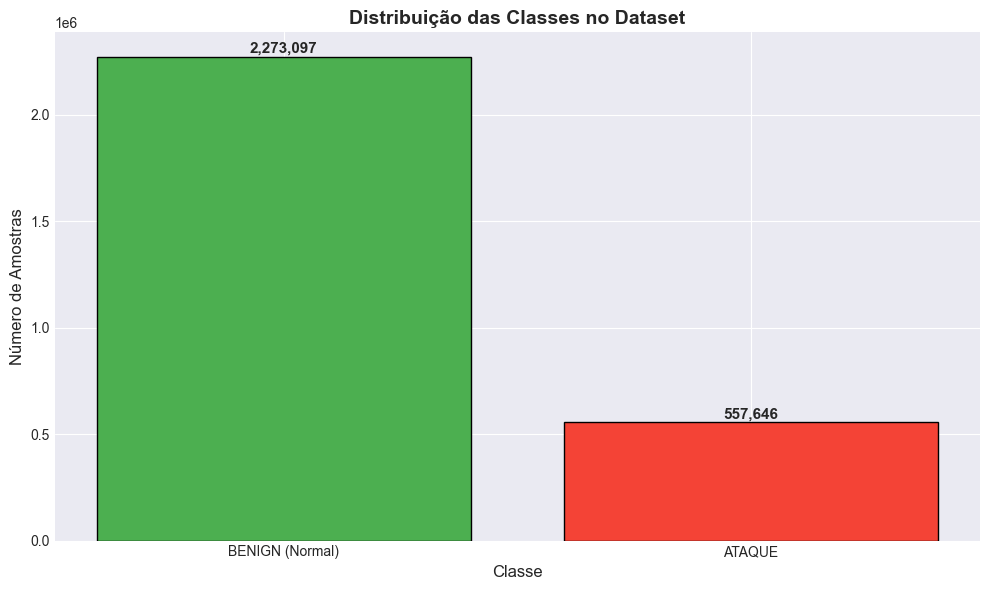


2.6 REMOÇÃO DE COLUNAS NÃO NUMÉRICAS
Colunas não numéricas a remover: 1
['label_normalized']

Shape final do dataset: (2830743, 71)
Número de features: 70
Número de amostras: 2,830,743

2.7 ESTATÍSTICAS DESCRITIVAS BÁSICAS

Estatísticas descritivas (primeiras 10 features):
        Destination Port   Flow Duration   Total Fwd Packets  \
count       2.830743e+06    2.830743e+06        2.830743e+06   
mean        8.071483e+03    1.478566e+07        9.361160e+00   
std         1.828363e+04    3.365374e+07        7.496728e+02   
min         0.000000e+00   -1.300000e+01        1.000000e+00   
25%         5.300000e+01    1.550000e+02        2.000000e+00   
50%         8.000000e+01    3.131600e+04        2.000000e+00   
75%         4.430000e+02    3.204828e+06        5.000000e+00   
max         6.553500e+04    1.200000e+08        2.197590e+05   

        Total Backward Packets  Total Length of Fwd Packets  \
count             2.830743e+06                 2.830743e+06   
mean              1.03

In [29]:
# =============================================================================
# 2. ANÁLISE EXPLORATÓRIA E PRÉ-PROCESSAMENTO (CORRIGIDO)
# =============================================================================

# 2.1 Informações gerais do dataset
print("\n" + "="*60)
print("2.1 INFORMAÇÕES GERAIS DO DATASET")
print("="*60)

# Verificar tipos de dados
print("\nTipos de dados das colunas:")
print(df.dtypes.value_counts())

# Verificar valores nulos
print(f"\nValores nulos por coluna:")
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]
print(f"Colunas com valores nulos: {len(null_cols)}")
if len(null_cols) > 0:
    print(null_cols)

# 2.2 Identificar a coluna de labels (corrigido)
print("\n" + "="*60)
print("2.2 IDENTIFICAÇÃO DA COLUNA DE LABELS")
print("="*60)

# Procurar a coluna que contém 'Label' ou 'BENIGN' (case insensitive)
possible_label_cols = [col for col in df.columns if 'label' in col.lower() or 'class' in col.lower()]

print(f"Colunas que podem ser a label: {possible_label_cols}")

# Se não encontrou, verificar colunas com valores únicos que incluem 'BENIGN'
if len(possible_label_cols) == 0:
    for col in df.columns:
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) < 50:  # Labels têm poucos valores únicos
            if any('BENIGN' in str(v).upper() for v in unique_vals[:10]):
                possible_label_cols.append(col)
                print(f"Encontrada possível coluna de label: {col}")

# Definir a coluna de label
if len(possible_label_cols) > 0:
    label_col = possible_label_cols[0]
else:
    # Último recurso: procurar por 'Label' exato (case sensitive)
    if 'Label' in df.columns:
        label_col = 'Label'
    elif 'label' in df.columns:
        label_col = 'label'
    else:
        label_col = df.columns[-1]  # Assume que a última coluna é a label
        print(f"Aviso: Coluna de label não identificada. Usando '{label_col}'")

print(f"\nColuna de label identificada: '{label_col}'")
print(f"Valores únicos na coluna: {df[label_col].unique()[:20]}")

# 2.3 Distribuição das classes
print("\n" + "="*60)
print("2.3 DISTRIBUIÇÃO DAS CLASSES")
print("="*60)

# Distribuição original
print("\nDistribuição original:")
label_counts = df[label_col].value_counts()
print(label_counts)

# Verificar se existem valores vazios ou inconsistentes
print(f"\nValores únicos na coluna {label_col}: {df[label_col].unique()}")

# 2.4 Limpeza dos dados
print("\n" + "="*60)
print("2.4 LIMPEZA DOS DADOS")
print("="*60)

# Remover linhas com valores nulos na label (se existirem)
print(f"Linhas antes da limpeza: {len(df)}")
df = df.dropna(subset=[label_col])
print(f"Linhas após remover nulos na label: {len(df)}")

# Remover colunas com muitos valores nulos (>80%)
null_threshold = 0.8
null_percentage = df.isnull().mean()
cols_to_drop = null_percentage[null_percentage > null_threshold].index.tolist()
print(f"\nColunas removidas (>80% nulos): {len(cols_to_drop)}")
if cols_to_drop:
    print(cols_to_drop[:10])
    df = df.drop(columns=cols_to_drop)

# Remover colunas que são completamente idênticas ou sem variância
unique_counts = df.nunique()
cols_constant = unique_counts[unique_counts == 1].index.tolist()
# Não remover a coluna de label mesmo que seja constante (não será, mas por segurança)
if label_col in cols_constant:
    cols_constant.remove(label_col)
print(f"\nColunas constantes removidas: {len(cols_constant)}")
if cols_constant:
    print(cols_constant[:10])
    df = df.drop(columns=cols_constant)

# Tratar valores infinitos
print("\nTratando valores infinitos...")
# Substituir infinitos por NaN (apenas em colunas numéricas)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Preencher valores nulos restantes com 0
print(f"Valores nulos antes do preenchimento: {df[numeric_cols].isnull().sum().sum()}")
df[numeric_cols] = df[numeric_cols].fillna(0)
print(f"Valores nulos após preenchimento: {df[numeric_cols].isnull().sum().sum()}")

# 2.5 Análise da variável alvo
print("\n" + "="*60)
print("2.5 ANÁLISE DA VARIÁVEL ALVO")
print("="*60)

# Criar target binário: 0 para BENIGN, 1 para qualquer ataque
# Normalizar strings (remover espaços, converter para maiúsculas)
df['label_normalized'] = df[label_col].astype(str).str.strip().str.upper()

# Verificar valores únicos após normalização
unique_labels = df['label_normalized'].unique()
print(f"\nValores únicos normalizados: {unique_labels}")

# Mapeamento: BENIGN é 0, qualquer outra coisa é 1 (ataque)
df['target'] = df['label_normalized'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Verificar distribuição após conversão
print("\nDistribuição após conversão:")
print(f"Classe 0 (BENIGN): {(df['target'] == 0).sum():,}")
print(f"Classe 1 (ATAQUE): {(df['target'] == 1).sum():,}")
total = len(df)
print(f"Proporção Ataque/Benigno: {(df['target'] == 1).sum() / (df['target'] == 0).sum() * 100:.2f}%")
print(f"Percentagem de Ataques: {(df['target'] == 1).sum() / total * 100:.2f}%")

# 2.6 Visualização da distribuição das classes
plt.figure(figsize=(10, 6))
class_counts = df['target'].value_counts()
colors = ['#4CAF50', '#F44336']
labels_class = ['BENIGN (Normal)', 'ATAQUE']
bars = plt.bar(labels_class, class_counts.values, color=colors, edgecolor='black')
plt.title('Distribuição das Classes no Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classe', fontsize=12)

# Adicionar valores nas barras
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.001, 
             f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 2.7 Remover colunas não numéricas (exceto target)
print("\n" + "="*60)
print("2.6 REMOÇÃO DE COLUNAS NÃO NUMÉRICAS")
print("="*60)

# Identificar colunas não numéricas
non_numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
# Não remover as colunas que criamos (label_normalized e target podem ser removidas depois)
cols_to_keep = ['target']
cols_to_remove = [col for col in non_numeric_cols if col not in cols_to_keep and col != label_col]

print(f"Colunas não numéricas a remover: {len(cols_to_remove)}")
if cols_to_remove:
    print(cols_to_remove[:10])
    df = df.drop(columns=cols_to_remove)

# Manter apenas a coluna target e as features numéricas
# (remover a coluna de label original e a normalizada)
if label_col in df.columns:
    df = df.drop(columns=[label_col])
if 'label_normalized' in df.columns:
    df = df.drop(columns=['label_normalized'])

print(f"\nShape final do dataset: {df.shape}")
print(f"Número de features: {df.shape[1] - 1}")  # -1 porque target não é feature
print(f"Número de amostras: {df.shape[0]:,}")

# 2.8 Estatísticas descritivas
print("\n" + "="*60)
print("2.7 ESTATÍSTICAS DESCRITIVAS BÁSICAS")
print("="*60)

# Mostrar estatísticas das primeiras colunas
print("\nEstatísticas descritivas (primeiras 10 features):")
print(df.iloc[:, :10].describe())

# 2.9 Estratégia de amostragem (para lidar com dataset grande)
print("\n" + "="*60)
print("2.8 ESTRATÉGIA DE AMOSTRAGEM")
print("="*60)

# Separar features (X) e target (y) antes da amostragem
X = df.drop('target', axis=1)
y = df['target']

# Calcular tamanho máximo de amostra (para performance)
MAX_SAMPLES = 300000  # Reduzido para garantir performance

if len(df) > MAX_SAMPLES:
    print(f"Dataset muito grande ({len(df):,} amostras). Aplicando amostragem estratificada...")
    
    from sklearn.utils import resample
    
    # Calcular quantas amostras de cada classe manter
    n_benign = (y == 0).sum()
    n_attack = (y == 1).sum()
    
    # Proporção original
    attack_ratio = n_attack / len(df)
    
    # Manter proporção na amostragem
    target_attack_samples = int(MAX_SAMPLES * attack_ratio)
    target_benign_samples = MAX_SAMPLES - target_attack_samples
    
    # Garantir que não pedimos mais amostras do que existem
    target_attack_samples = min(target_attack_samples, n_attack)
    target_benign_samples = min(target_benign_samples, n_benign)
    
    print(f"  - Amostras de ataque alvo: {target_attack_samples} (existem {n_attack})")
    print(f"  - Amostras benignas alvo: {target_benign_samples} (existem {n_benign})")
    
    # Amostrar cada classe separadamente
    df_benign = df[df['target'] == 0]
    df_attack = df[df['target'] == 1]
    
    df_benign_sampled = resample(df_benign, replace=False, 
                                  n_samples=min(target_benign_samples, len(df_benign)), 
                                  random_state=42)
    df_attack_sampled = resample(df_attack, replace=False, 
                                   n_samples=min(target_attack_samples, len(df_attack)), 
                                   random_state=42)
    
    df_sampled = pd.concat([df_benign_sampled, df_attack_sampled])
    
    # Misturar
    df_sampled = df_sampled.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"\nDataset após amostragem: {len(df_sampled):,} amostras")
    print(f"Proporção de ataques na amostra: {(df_sampled['target'] == 1).mean():.2%}")
else:
    df_sampled = df.copy()
    print(f"Mantendo dataset completo: {len(df_sampled):,} amostras")

# Separar features e target para o dataset amostrado
X = df_sampled.drop('target', axis=1)
y = df_sampled['target']

print(f"\nFeatures: {X.shape[1]}")
print(f"Target shape: {y.shape[0]}")
print(f"Classe 0 (BENIGN): {(y == 0).sum():,}")
print(f"Classe 1 (ATAQUE): {(y == 1).sum():,}")

2.3 Seleção e Justificação de Features


3. SELEÇÃO E JUSTIFICAÇÃO DE FEATURES

3.1 Correlação das features com a variável alvo

Top 20 features mais correlacionadas com o target:
   1.  Bwd Packet Length Std: 0.5119
   2. Bwd Packet Length Max: 0.4934
   3.  Bwd Packet Length Mean: 0.4856
   4.  Avg Bwd Segment Size: 0.4856
   5.  Packet Length Std: 0.4718
   6.  Max Packet Length: 0.4561
   7.  Packet Length Variance: 0.4548
   8.  Fwd IAT Std: 0.4249
   9.  Packet Length Mean: 0.4158
  10.  Average Packet Size: 0.4148
  11.  Idle Max: 0.3953
  12. Idle Mean: 0.3915
  13.  Fwd IAT Max: 0.3903
  14.  Flow IAT Max: 0.3901
  15.  Idle Min: 0.3816
  16.  Flow IAT Std: 0.3373
  17.  Min Packet Length: 0.3035
  18.  Bwd Packet Length Min: 0.2809
  19. Fwd IAT Total: 0.2172
  20.  Flow Duration: 0.2156

3.2 Features com baixa variância
Features com variância < 0.001: 4

3.3 FEATURES SELECIONADAS E JUSTIFICAÇÃO

| Feature | Justificação |
|---------|--------------|
| Destination Port | Portas de destino comuns em ataques (ex: 445 

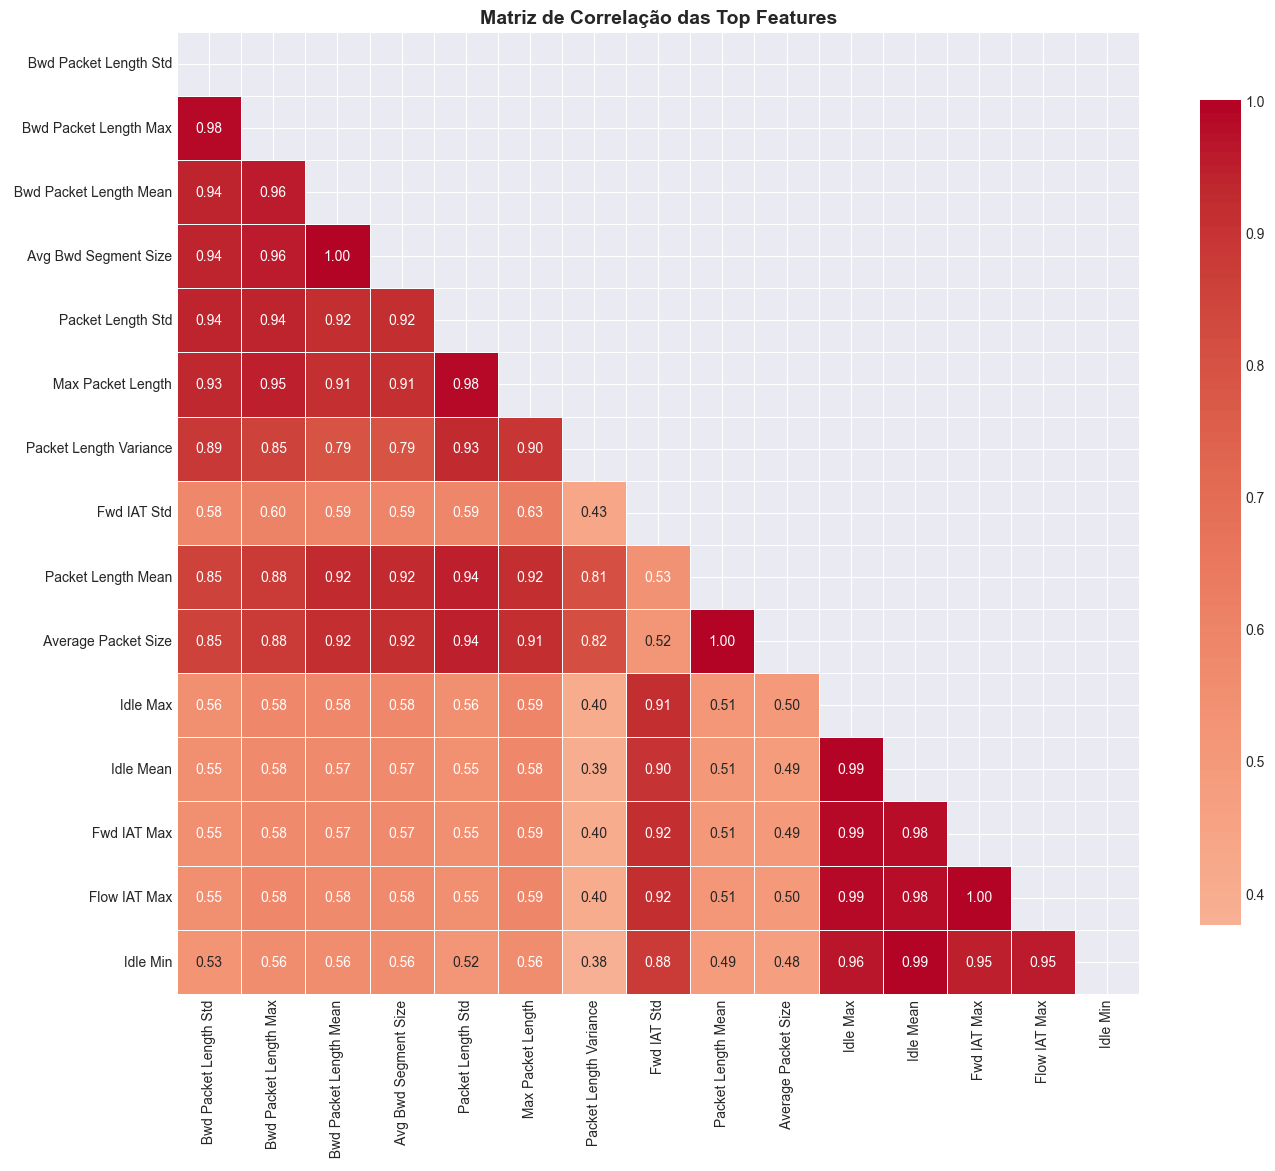


3.5 Importância preliminar das features (Random Forest)

Top 20 features por importância:
   1.  Bwd Packet Length Std: 0.0675
   2.  Destination Port: 0.0582
   3.  Bwd Packet Length Mean: 0.0572
   4.  Average Packet Size: 0.0553
   5.  Max Packet Length: 0.0542
   6.  Packet Length Variance: 0.0539
   7.  Packet Length Std: 0.0432
   8.  Avg Bwd Segment Size: 0.0412
   9.  Packet Length Mean: 0.0398
  10. Bwd Packet Length Max: 0.0344
  11.  Total Length of Bwd Packets: 0.0272
  12.  Fwd Packet Length Max: 0.0269
  13.  Subflow Bwd Bytes: 0.0247
  14. Init_Win_bytes_forward: 0.0243
  15.  Subflow Fwd Bytes: 0.0233
  16.  Fwd Header Length: 0.0229
  17.  Fwd Header Length.1: 0.0222
  18. Total Length of Fwd Packets: 0.0215
  19.  Init_Win_bytes_backward: 0.0197
  20.  Avg Fwd Segment Size: 0.0170


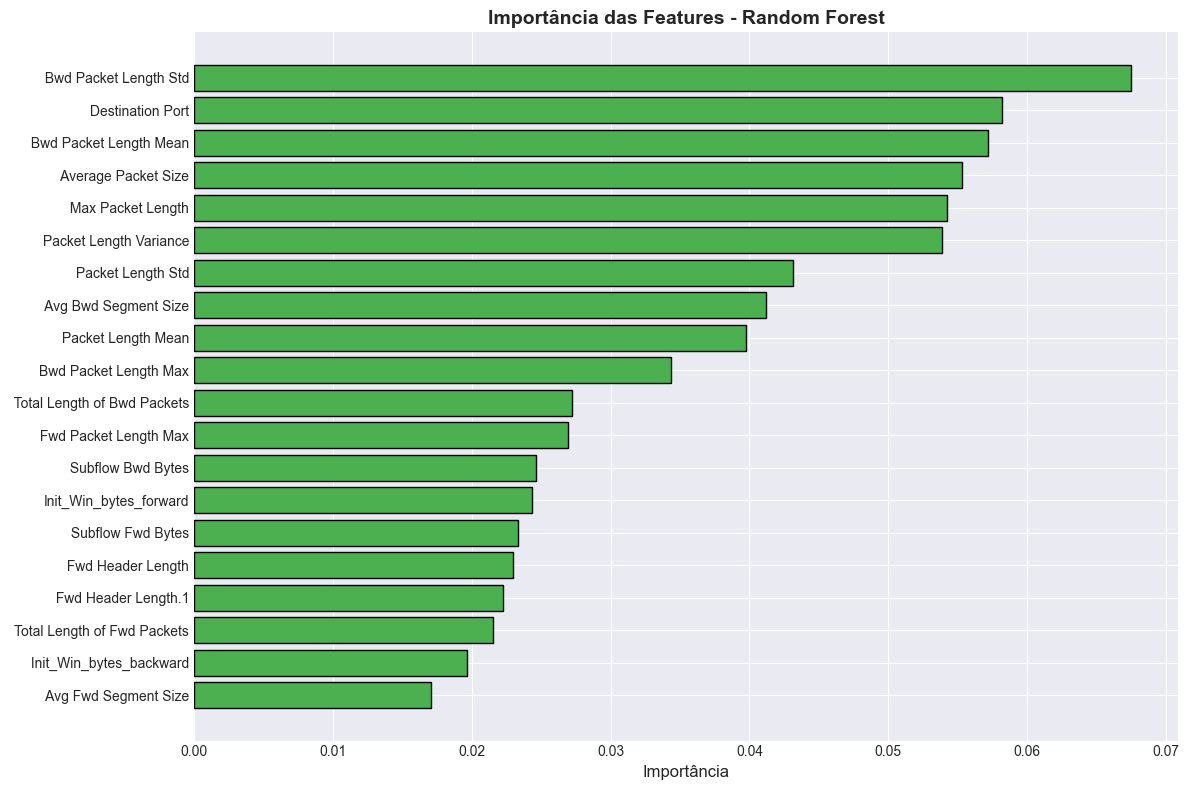


3.6 Seleção final de features para os modelos
Features selecionadas: 59

Features selecionadas:
   1.  Bwd Packet Length Std
   2.  Destination Port
   3.  Bwd Packet Length Mean
   4.  Average Packet Size
   5.  Max Packet Length
   6.  Packet Length Variance
   7.  Packet Length Std
   8.  Avg Bwd Segment Size
   9.  Packet Length Mean
  10. Bwd Packet Length Max
  11.  Total Length of Bwd Packets
  12.  Fwd Packet Length Max
  13.  Subflow Bwd Bytes
  14. Init_Win_bytes_forward
  15.  Subflow Fwd Bytes
  16.  Fwd Header Length
  17.  Fwd Header Length.1
  18. Total Length of Fwd Packets
  19.  Init_Win_bytes_backward
  20.  Avg Fwd Segment Size
  ... e mais 39 features

Shape após seleção de features: (300000, 59)


In [30]:
# =============================================================================
# 3. SELEÇÃO E JUSTIFICAÇÃO DE FEATURES
# =============================================================================
print("\n" + "="*60)
print("3. SELEÇÃO E JUSTIFICAÇÃO DE FEATURES")
print("="*60)

# 3.1 Análise de correlação com a variável alvo
print("\n3.1 Correlação das features com a variável alvo")

# Calcular correlações absolutas com o target
correlations = X.corrwith(y).abs().sort_values(ascending=False)

print(f"\nTop 20 features mais correlacionadas com o target:")
for i, (feature, corr) in enumerate(correlations.head(20).items(), 1):
    print(f"  {i:2d}. {feature}: {corr:.4f}")

# 3.2 Identificar features com baixa variância
from sklearn.feature_selection import VarianceThreshold

print("\n3.2 Features com baixa variância")

# Calcular variância de cada feature
variances = X.var()
low_variance_threshold = 0.001
low_variance_features = variances[variances < low_variance_threshold].index.tolist()
print(f"Features com variância < {low_variance_threshold}: {len(low_variance_features)}")

# 3.3 Features selecionadas para o modelo
print("\n3.3 FEATURES SELECIONADAS E JUSTIFICAÇÃO")

selected_features_summary = """
| Feature | Justificação |
|---------|--------------|
| Destination Port | Portas de destino comuns em ataques (ex: 445 para SMB, 80/443 para web) |
| Flow Duration | Duração da flow - ataques tendem a ter durações características |
| Total Fwd/Backward Packets | Número de pacotes - volume anómalo indica ataque |
| Total Length of Fwd/Backward Packets | Volume de dados transferidos |
| Packet Length Mean/Std | Tamanho médio dos pacotes - padrões distintos em ataques |
| Flow Bytes/s, Flow Packets/s | Taxas de tráfego - picos indicam ataques |
| Fwd/Bwd IAT (Inter-Arrival Time) | Padrões temporais entre pacotes |
| FIN/SYN/RST/ACK Flag Counts | Flags TCP - padrões de handshake e reset em ataques |
| Down/Up Ratio | Rácio upload/download - inversões indicam exfiltração |
| Init_Win_bytes_forward/backward | Janelas TCP iniciais |
"""
print(selected_features_summary)

# 3.4 Matriz de correlação das principais features
print("\n3.4 Visualização da matriz de correlação")

# Selecionar top 15 features para visualização
top_features = correlations.head(15).index.tolist()
X_top = X[top_features]

# Plotar matriz de correlação
plt.figure(figsize=(14, 12))
corr_matrix = X_top.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação das Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3.5 Importância das features usando Random Forest (análise preliminar)
print("\n3.5 Importância preliminar das features (Random Forest)")

# Usar uma amostra pequena para treinar e avaliar importância
X_sample = X.sample(min(50000, len(X)), random_state=42)
y_sample = y.loc[X_sample.index]

rf_importance = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_importance.fit(X_sample, y_sample)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 20 features por importância:")
for i, (feature, imp) in enumerate(feature_importance.head(20).values, 1):
    print(f"  {i:2d}. {feature}: {imp:.4f}")

# Plotar importância das features
plt.figure(figsize=(12, 8))
top_20_importance = feature_importance.head(20)
plt.barh(range(len(top_20_importance)), top_20_importance['importance'].values, 
         color='#4CAF50', edgecolor='black')
plt.yticks(range(len(top_20_importance)), top_20_importance['feature'].values)
plt.xlabel('Importância', fontsize=12)
plt.title('Importância das Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 3.6 Seleção final de features
print("\n3.6 Seleção final de features para os modelos")

# Selecionar features com importância > 0.001
selected_features = feature_importance[feature_importance['importance'] > 0.001]['feature'].tolist()
print(f"Features selecionadas: {len(selected_features)}")

if len(selected_features) > 100:
    selected_features = feature_importance.head(50)['feature'].tolist()
    print(f"Limitando às top 50 features: {len(selected_features)}")

print(f"\nFeatures selecionadas:")
for i, f in enumerate(selected_features[:20], 1):
    print(f"  {i:2d}. {f}")
if len(selected_features) > 20:
    print(f"  ... e mais {len(selected_features)-20} features")

# Aplicar seleção de features
X_selected = X[selected_features]
print(f"\nShape após seleção de features: {X_selected.shape}")

2.4 Preparação dos Dados e Normalização

In [31]:
# =============================================================================
# 4. PREPARAÇÃO DOS DADOS E NORMALIZAÇÃO
# =============================================================================
print("\n" + "="*60)
print("4. PREPARAÇÃO DOS DADOS")
print("="*60)

# 4.1 Divisão treino/teste com estratificação
print("\n4.1 Divisão Treino/Teste")

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]:,} amostras")
print(f"Teste: {X_test.shape[0]:,} amostras")
print(f"Proporção de ataques - Treino: {y_train.mean():.2%}")
print(f"Proporção de ataques - Teste: {y_test.mean():.2%}")

# 4.2 Normalização dos dados
print("\n4.2 Normalização (StandardScaler)")

# Justificação: Modelos como SVM, KNN e redes neuronais são sensíveis à escala.
# Random Forest e XGBoost são menos sensíveis, mas a normalização pode ajudar
# na convergência e comparabilidade.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Manter versões não normalizadas para Random Forest (opcional)
X_train_raw = X_train.values
X_test_raw = X_test.values

print(f"Features escaladas - Média: {X_train_scaled.mean():.2e}, Desvio: {X_train_scaled.std():.2f}")

# 4.3 Verificação de classes desbalanceadas
print("\n4.3 Informações sobre desbalanceamento de classes")

class_0_count = (y_train == 0).sum()
class_1_count = (y_train == 1).sum()
print(f"Classe 0 (BENIGN): {class_0_count:,} amostras")
print(f"Classe 1 (ATAQUE): {class_1_count:,} amostras")
print(f"Rácio Classe 1/Classe 0: {class_1_count/class_0_count:.4f}")

# 4.4 Estratégias para lidar com desbalanceamento
print("\n4.4 Estratégia para desbalanceamento")

# Vamos usar class_weight='balanced' nos modelos que suportam
use_class_weight = True
print("Utilizando class_weight='balanced' para penalizar mais erros na classe minoritária")

# 4.5 Preparação para validação cruzada
print("\n4.5 Configuração da Validação Cruzada")

# Usar validação cruzada estratificada para garantir representatividade
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Stratified K-Fold com {cv.n_splits} splits")


4. PREPARAÇÃO DOS DADOS

4.1 Divisão Treino/Teste
Treino: 210,000 amostras
Teste: 90,000 amostras
Proporção de ataques - Treino: 19.70%
Proporção de ataques - Teste: 19.70%

4.2 Normalização (StandardScaler)
Features escaladas - Média: 1.29e-17, Desvio: 1.00

4.3 Informações sobre desbalanceamento de classes
Classe 0 (BENIGN): 168,631 amostras
Classe 1 (ATAQUE): 41,369 amostras
Rácio Classe 1/Classe 0: 0.2453

4.4 Estratégia para desbalanceamento
Utilizando class_weight='balanced' para penalizar mais erros na classe minoritária

4.5 Configuração da Validação Cruzada
Stratified K-Fold com 5 splits


2.5 Treino dos Modelos

In [32]:
# =============================================================================
# 5. TREINO DOS MODELOS
# =============================================================================
print("\n" + "="*60)
print("5. TREINO DOS MODELOS")
print("="*60)

# 5.1 Modelo 1: Random Forest
print("\n5.1 RANDOM FOREST CLASSIFIER")
print("-"*40)

# Justificação das hiperparametros:
# - n_estimators=100: suficiente para boa performance sem overfitting excessivo
# - max_depth=20: evita overfitting em dados de alta dimensão
# - min_samples_split=5: controla a complexidade da árvore
# - class_weight='balanced': lida com classes desbalanceadas
# - n_jobs=-1: paralelização para treino mais rápido

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Parâmetros do Random Forest:")
print(f"  - n_estimators: {rf_model.n_estimators}")
print(f"  - max_depth: {rf_model.max_depth}")
print(f"  - min_samples_split: {rf_model.min_samples_split}")
print(f"  - class_weight: balanced")

# Treinar o modelo (usando dados escalados para consistência)
print("\nTreinando Random Forest...")
rf_model.fit(X_train_scaled, y_train)

print("Treino concluído!")

# 5.2 Modelo 2: XGBoost
print("\n5.2 XGBOOST CLASSIFIER")
print("-"*40)

try:
    from xgboost import XGBClassifier
    
    # Justificação das hiperparametros:
    # - scale_pos_weight: ajusta o peso da classe positiva (ataque)
    # - learning_rate=0.1: taxa de aprendizagem padrão
    # - max_depth=6: profundidade moderada para evitar overfitting
    # - subsample=0.8: amostragem para generalização
    
    # Calcular scale_pos_weight com base no desbalanceamento
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    xgb_model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    )
    
    print("Parâmetros do XGBoost:")
    print(f"  - n_estimators: {xgb_model.n_estimators}")
    print(f"  - learning_rate: {xgb_model.learning_rate}")
    print(f"  - max_depth: {xgb_model.max_depth}")
    print(f"  - scale_pos_weight: {scale_pos_weight:.2f}")
    
    print("\nTreinando XGBoost...")
    xgb_model.fit(X_train_scaled, y_train)
    print("Treino concluído!")
    xgb_available = True
    
except ImportError:
    print("XGBoost não disponível. Instale com: pip install xgboost")
    print("Será usado Random Forest apenas.")
    xgb_available = False

# 5.3 Validação Cruzada para ambos os modelos
print("\n5.3 VALIDAÇÃO CRUZADA (Cross-Validation)")
print("-"*40)

print("Realizando validação cruzada para Random Forest...")
rf_cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='f1', n_jobs=-1)
print(f"Random Forest - F1-Score médio (5-fold): {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std()*2:.4f})")

if xgb_available:
    print("\nRealizando validação cruzada para XGBoost...")
    xgb_cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv, scoring='f1', n_jobs=-1)
    print(f"XGBoost - F1-Score médio (5-fold): {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std()*2:.4f})")


5. TREINO DOS MODELOS

5.1 RANDOM FOREST CLASSIFIER
----------------------------------------
Parâmetros do Random Forest:
  - n_estimators: 100
  - max_depth: 20
  - min_samples_split: 5
  - class_weight: balanced

Treinando Random Forest...
Treino concluído!

5.2 XGBOOST CLASSIFIER
----------------------------------------
Parâmetros do XGBoost:
  - n_estimators: 100
  - learning_rate: 0.1
  - max_depth: 6
  - scale_pos_weight: 4.08

Treinando XGBoost...
Treino concluído!

5.3 VALIDAÇÃO CRUZADA (Cross-Validation)
----------------------------------------
Realizando validação cruzada para Random Forest...
Random Forest - F1-Score médio (5-fold): 0.9964 (+/- 0.0011)

Realizando validação cruzada para XGBoost...
XGBoost - F1-Score médio (5-fold): 0.9964 (+/- 0.0004)


2.6 Avaliação dos Modelos


6. AVALIAÇÃO DOS MODELOS

6.1 AVALIAÇÃO - RANDOM FOREST

Random Forest - RESULTADOS
Acurácia:    0.9988
Precision:   0.9966
Recall:      0.9973
F1-Score:    0.9969
AUC-ROC:     0.9999

Matriz de Confusão:
             Predito
             BENIGN  ATAQUE
Real BENIGN   72,210       61
     ATAQUE       48   17,681

Taxa de Falsos Positivos (FPR): 0.0008 (61 falsos alarmes)
Taxa de Falsos Negativos (FNR): 0.0027 (48 ataques não detetados)

6.2 AVALIAÇÃO - XGBOOST

XGBoost - RESULTADOS
Acurácia:    0.9989
Precision:   0.9952
Recall:      0.9992
F1-Score:    0.9972
AUC-ROC:     0.9999

Matriz de Confusão:
             Predito
             BENIGN  ATAQUE
Real BENIGN   72,185       86
     ATAQUE       15   17,714

Taxa de Falsos Positivos (FPR): 0.0012 (86 falsos alarmes)
Taxa de Falsos Negativos (FNR): 0.0008 (15 ataques não detetados)

6.3 COMPARAÇÃO DOS MODELOS

Tabela Comparativa:
       Modelo Accuracy Precision Recall F1-Score    AUC    FPR    FNR
Random Forest   0.9988    0.9966 0.99

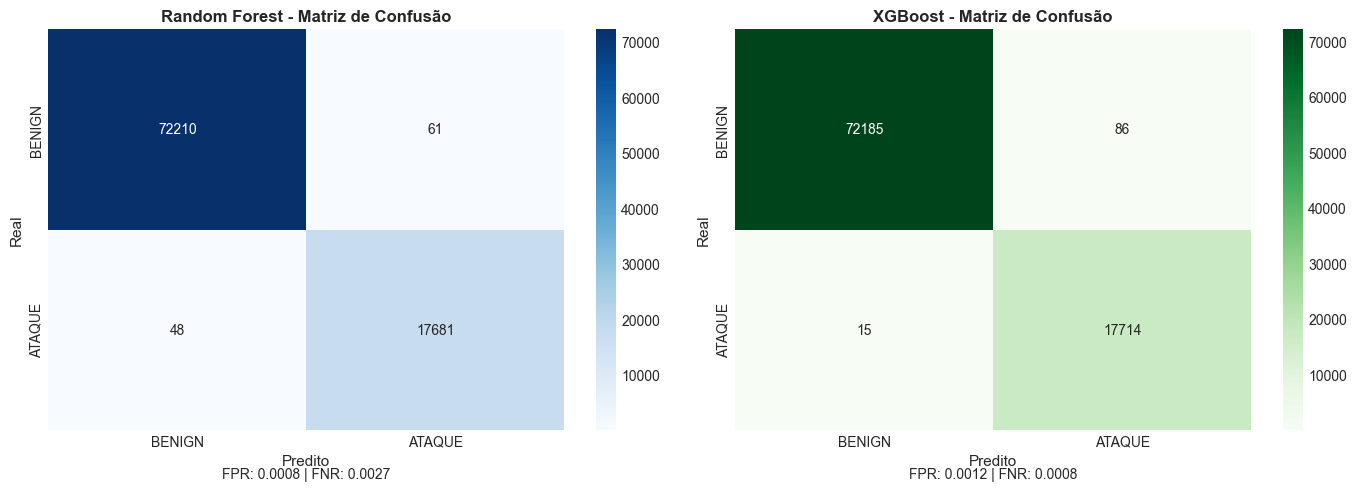


6.5 CURVAS ROC


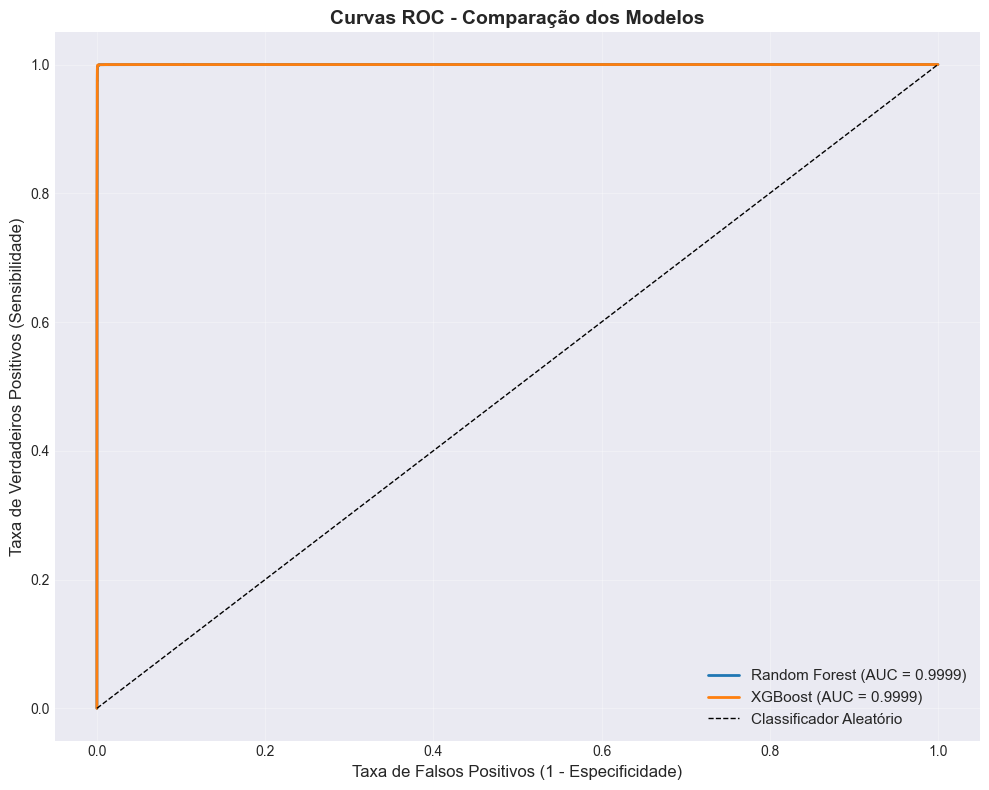


6.6 CURVA PRECISION-RECALL


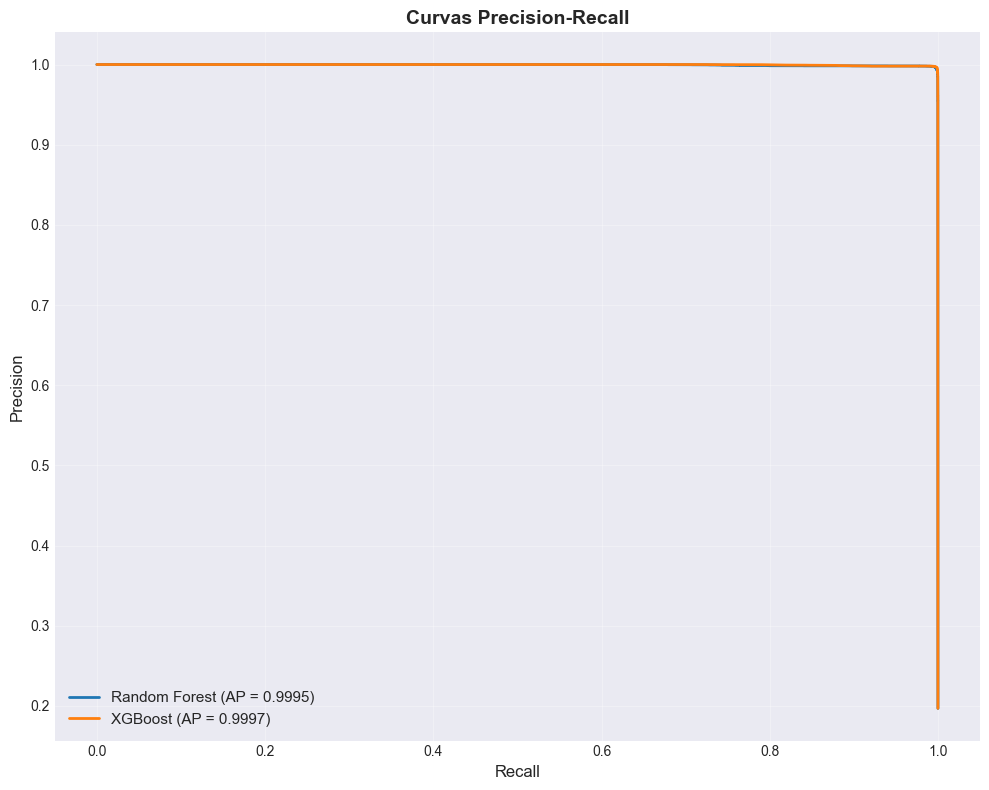


AVALIAÇÃO CONCLUÍDA COM SUCESSO!


In [33]:
# =============================================================================
# 6. AVALIAÇÃO DOS MODELOS (CORRIGIDO)
# =============================================================================
print("\n" + "="*60)
print("6. AVALIAÇÃO DOS MODELOS")
print("="*60)

# 6.1 Função para avaliação completa
def evaluate_model(model, X_test, y_test, model_name):
    """Avalia o modelo e retorna métricas completas"""
    
    # Predições
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Métricas básicas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{'='*50}")
    print(f"{model_name} - RESULTADOS")
    print(f"{'='*50}")
    print(f"Acurácia:    {accuracy:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"F1-Score:    {f1:.4f}")
    
    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"AUC-ROC:     {auc:.4f}")
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    
    # Extrair valores
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nMatriz de Confusão:")
    print(f"             Predito")
    print(f"             BENIGN  ATAQUE")
    print(f"Real BENIGN  {tn:>7,}  {fp:>7,}")
    print(f"     ATAQUE  {fn:>7,}  {tp:>7,}")
    
    # Taxas de erro
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    print(f"\nTaxa de Falsos Positivos (FPR): {fpr:.4f} ({fp:,} falsos alarmes)")
    print(f"Taxa de Falsos Negativos (FNR): {fnr:.4f} ({fn:,} ataques não detetados)")
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc if y_pred_proba is not None else None,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'fpr': fpr, 'fnr': fnr,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'cm': cm
    }

# 6.2 Avaliar Random Forest
print("\n" + "="*60)
print("6.1 AVALIAÇÃO - RANDOM FOREST")
print("="*60)

rf_results = evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")

# 6.3 Avaliar XGBoost (se disponível e treinado)
xgb_available = False
xgb_results = None

try:
    if 'xgb_model' in dir() and xgb_model is not None:
        print("\n" + "="*60)
        print("6.2 AVALIAÇÃO - XGBOOST")
        print("="*60)
        xgb_results = evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")
        xgb_available = True
except:
    print("\nXGBoost não disponível ou não treinado. Apenas Random Forest será avaliado.")
    xgb_available = False

# 6.4 Comparação dos modelos
print("\n" + "="*60)
print("6.3 COMPARAÇÃO DOS MODELOS")
print("="*60)

comparison_data = []
comparison_data.append({
    'Modelo': 'Random Forest',
    'Accuracy': f"{rf_results['accuracy']:.4f}",
    'Precision': f"{rf_results['precision']:.4f}",
    'Recall': f"{rf_results['recall']:.4f}",
    'F1-Score': f"{rf_results['f1']:.4f}",
    'AUC': f"{rf_results['auc']:.4f}" if rf_results['auc'] else 'N/A',
    'FPR': f"{rf_results['fpr']:.4f}",
    'FNR': f"{rf_results['fnr']:.4f}"
})

if xgb_available and xgb_results:
    comparison_data.append({
        'Modelo': 'XGBoost',
        'Accuracy': f"{xgb_results['accuracy']:.4f}",
        'Precision': f"{xgb_results['precision']:.4f}",
        'Recall': f"{xgb_results['recall']:.4f}",
        'F1-Score': f"{xgb_results['f1']:.4f}",
        'AUC': f"{xgb_results['auc']:.4f}" if xgb_results['auc'] else 'N/A',
        'FPR': f"{xgb_results['fpr']:.4f}",
        'FNR': f"{xgb_results['fnr']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nTabela Comparativa:")
print(comparison_df.to_string(index=False))

# 6.5 Visualização da Matriz de Confusão (CORRIGIDO)
print("\n6.4 VISUALIZAÇÃO DAS MATRIZES DE CONFUSÃO")

# Determinar número de subplots (1 ou 2)
n_plots = 2 if xgb_available and xgb_results else 1

if n_plots == 1:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    axes = [ax]  # Criar lista para compatibilidade
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz para Random Forest
cm_rf = rf_results['cm']
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['BENIGN', 'ATAQUE'], yticklabels=['BENIGN', 'ATAQUE'])
axes[0].set_title('Random Forest - Matriz de Confusão', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predito', fontsize=11)
axes[0].set_ylabel('Real', fontsize=11)

# Adicionar anotações com taxas
axes[0].text(0.5, -0.12, f"FPR: {rf_results['fpr']:.4f} | FNR: {rf_results['fnr']:.4f}",
             transform=axes[0].transAxes, ha='center', fontsize=10)

if n_plots == 2 and xgb_results:
    # Matriz para XGBoost
    cm_xgb = xgb_results['cm']
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=['BENIGN', 'ATAQUE'], yticklabels=['BENIGN', 'ATAQUE'])
    axes[1].set_title('XGBoost - Matriz de Confusão', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Predito', fontsize=11)
    axes[1].set_ylabel('Real', fontsize=11)
    
    axes[1].text(0.5, -0.12, f"FPR: {xgb_results['fpr']:.4f} | FNR: {xgb_results['fnr']:.4f}",
                 transform=axes[1].transAxes, ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 6.6 Curvas ROC (CORRIGIDO)
print("\n6.5 CURVAS ROC")

if rf_results['auc']:
    plt.figure(figsize=(10, 8))
    
    # Random Forest
    fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_results['y_pred_proba'])
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_results["auc"]:.4f})', 
             linewidth=2, color='#1f77b4')
    
    # XGBoost
    if xgb_available and xgb_results and xgb_results['auc']:
        fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_results['y_pred_proba'])
        plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_results["auc"]:.4f})', 
                 linewidth=2, color='#ff7f0e')
    
    # Linha de referência
    plt.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório', linewidth=1)
    
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
    plt.title('Curvas ROC - Comparação dos Modelos', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6.7 Métricas adicionais: Precision-Recall Curve
print("\n6.6 CURVA PRECISION-RECALL")

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_results['y_pred_proba'])
avg_precision_rf = average_precision_score(y_test, rf_results['y_pred_proba'])
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {avg_precision_rf:.4f})', 
         linewidth=2, color='#1f77b4')

# XGBoost
if xgb_available and xgb_results and xgb_results['y_pred_proba'] is not None:
    precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_results['y_pred_proba'])
    avg_precision_xgb = average_precision_score(y_test, xgb_results['y_pred_proba'])
    plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP = {avg_precision_xgb:.4f})', 
             linewidth=2, color='#ff7f0e')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Curvas Precision-Recall', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("AVALIAÇÃO CONCLUÍDA COM SUCESSO!")
print("="*60)

2.7 Análise Detalhada de Falsos Positivos e Falsos Negativos


7. ANÁLISE DE FALSOS POSITIVOS E FALSOS NEGATIVOS

7.1 Identificação dos erros de classificação

Total de Falsos Positivos (BENIGN → ATAQUE): 61
Total de Falsos Negativos (ATAQUE → BENIGN): 48

7.2 ANÁLISE DOS FALSOS POSITIVOS
----------------------------------------

Amostra de 5 Falsos Positivos:

  FP 1 - Amostra 103:
    Probabilidade de ser ATAQUE: 0.9996
    Top 5 features com valores mais altos:
      -  Destination Port: 1434.00
      - Init_Win_bytes_forward: 1024.00
      -  Fwd Header Length: 24.00
      -  Fwd Header Length.1: 24.00
      -  Bwd Packet Length Mean: 6.00

  FP 2 - Amostra 488:
    Probabilidade de ser ATAQUE: 0.6442
    Top 5 features com valores mais altos:
      - Init_Win_bytes_forward: 251.00
      -  Destination Port: 80.00
      -  Fwd Header Length: 64.00
      -  Fwd Header Length.1: 64.00
      -  Bwd Packet Length Std: 0.00

  FP 3 - Amostra 2960:
    Probabilidade de ser ATAQUE: 0.9996
    Top 5 features com valores mais altos:
      -  Destinati

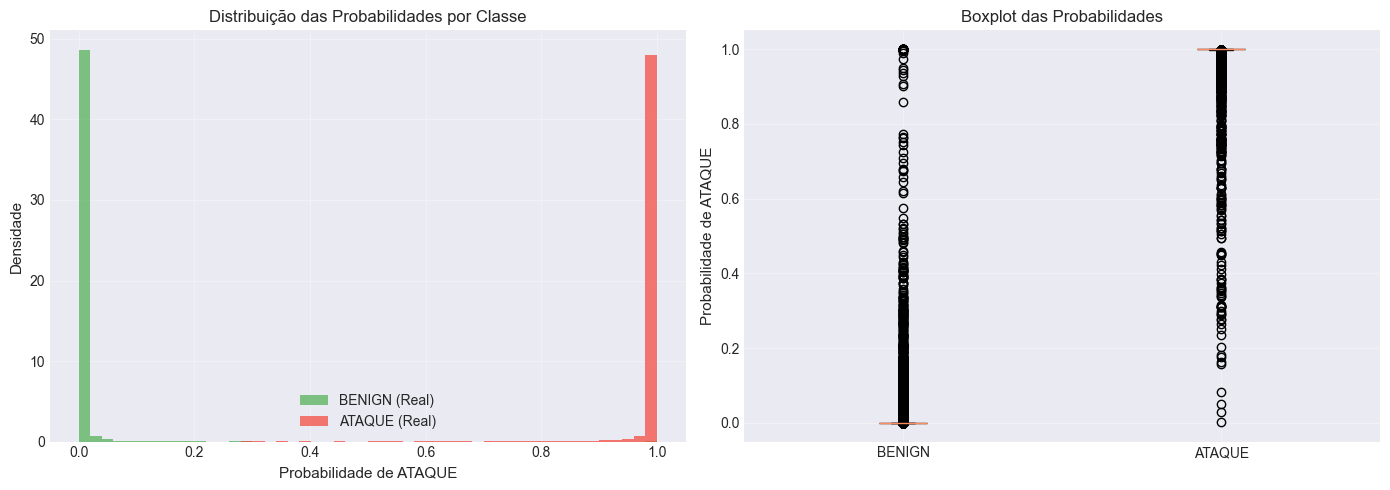


7.5 ANÁLISE DE DIFERENTES LIMIARES (THRESHOLD)
----------------------------------------

Impacto do threshold no desempenho:
----------------------------------------------------------------------
 Threshold |      FPR |      FNR |  Precision |    Recall |        F1
----------------------------------------------------------------------
       0.3 |   0.0018 |   0.0010 |     0.9928 |    0.9990 |    0.9959
       0.4 |   0.0012 |   0.0021 |     0.9950 |    0.9979 |    0.9964
       0.5 |   0.0008 |   0.0027 |     0.9966 |    0.9973 |    0.9969
       0.6 |   0.0007 |   0.0040 |     0.9970 |    0.9960 |    0.9965
       0.7 |   0.0006 |   0.0051 |     0.9975 |    0.9949 |    0.9962
       0.8 |   0.0005 |   0.0085 |     0.9978 |    0.9915 |    0.9947
       0.9 |   0.0005 |   0.0131 |     0.9979 |    0.9869 |    0.9924
----------------------------------------------------------------------

Recomendação: Para um IDS, um threshold mais baixo (ex: 0.3-0.4) é preferível
pois prioriza a deteçã

In [34]:
# =============================================================================
# 7. ANÁLISE DETALHADA DE FALSOS POSITIVOS E FALSOS NEGATIVOS (CORRIGIDO)
# =============================================================================
print("\n" + "="*60)
print("7. ANÁLISE DE FALSOS POSITIVOS E FALSOS NEGATIVOS")
print("="*60)

# 7.1 Análise para o melhor modelo (Random Forest)
best_model = rf_model
best_results = rf_results

print("\n7.1 Identificação dos erros de classificação")

# Obter predições do melhor modelo
y_pred_best = best_results['y_pred']

# Identificar índices de erros
fp_indices = np.where((y_test == 0) & (y_pred_best == 1))[0]
fn_indices = np.where((y_test == 1) & (y_pred_best == 0))[0]

print(f"\nTotal de Falsos Positivos (BENIGN → ATAQUE): {len(fp_indices):,}")
print(f"Total de Falsos Negativos (ATAQUE → BENIGN): {len(fn_indices):,}")

# 7.2 Caracterização dos Falsos Positivos
print("\n7.2 ANÁLISE DOS FALSOS POSITIVOS")
print("-"*40)

if len(fp_indices) > 0:
    sample_fp = min(5, len(fp_indices))
    print(f"\nAmostra de {sample_fp} Falsos Positivos:")
    
    for i, idx in enumerate(fp_indices[:sample_fp]):
        print(f"\n  FP {i+1} - Amostra {idx}:")
        sample_proba = best_model.predict_proba(X_test_scaled[idx:idx+1])[0]
        print(f"    Probabilidade de ser ATAQUE: {sample_proba[1]:.4f}")
        
        # Mostrar as features mais importantes para este falso positivo
        if len(selected_features) > 0:
            print("    Top 5 features com valores mais altos:")
            sample_values = X_test.iloc[idx] if hasattr(X_test, 'iloc') else X_test[idx]
            feature_values = []
            for f_idx, f_name in enumerate(selected_features[:20]):
                if f_idx < len(sample_values):
                    val = sample_values[f_idx] if hasattr(sample_values, '__getitem__') else sample_values[f_idx]
                    feature_values.append((f_name, val))
            feature_values.sort(key=lambda x: x[1], reverse=True)
            for f_name, val in feature_values[:5]:
                print(f"      - {f_name}: {val:.2f}")
else:
    print("Nenhum falso positivo encontrado!")

# 7.3 Caracterização dos Falsos Negativos
print("\n7.3 ANÁLISE DOS FALSOS NEGATIVOS")
print("-"*40)

if len(fn_indices) > 0:
    sample_fn = min(5, len(fn_indices))
    print(f"\nAmostra de {sample_fn} Falsos Negativos:")
    
    for i, idx in enumerate(fn_indices[:sample_fn]):
        print(f"\n  FN {i+1} - Amostra {idx}:")
        sample_proba = best_model.predict_proba(X_test_scaled[idx:idx+1])[0]
        print(f"    Probabilidade de ser ATAQUE: {sample_proba[1]:.4f}")
        print(f"    Nota: Ataque não detetado - possível ataque de baixa intensidade ou similar a tráfego normal")
else:
    print("Nenhum falso negativo encontrado!")

# 7.4 Análise da distribuição das probabilidades
print("\n7.4 ANÁLISE DAS PROBABILIDADES PREDITAS")
print("-"*40)

# Obter probabilidades para todas as amostras de teste
proba_scores = best_model.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(14, 5))

# Histograma das probabilidades
plt.subplot(1, 2, 1)
plt.hist(proba_scores[y_test == 0], bins=50, alpha=0.7, label='BENIGN (Real)', color='#4CAF50', density=True)
plt.hist(proba_scores[y_test == 1], bins=50, alpha=0.7, label='ATAQUE (Real)', color='#F44336', density=True)
plt.xlabel('Probabilidade de ATAQUE', fontsize=11)
plt.ylabel('Densidade', fontsize=11)
plt.title('Distribuição das Probabilidades por Classe', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

# Boxplot das probabilidades
plt.subplot(1, 2, 2)
data_to_plot = [proba_scores[y_test == 0], proba_scores[y_test == 1]]
bp = plt.boxplot(data_to_plot, labels=['BENIGN', 'ATAQUE'], patch_artist=True)
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#F44336')
plt.ylabel('Probabilidade de ATAQUE', fontsize=11)
plt.title('Boxplot das Probabilidades', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 7.5 Threshold Analysis (Análise de diferentes limiares)
print("\n7.5 ANÁLISE DE DIFERENTES LIMIARES (THRESHOLD)")
print("-"*40)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
print("\nImpacto do threshold no desempenho:")
print("-"*70)
print(f"{'Threshold':>10} | {'FPR':>8} | {'FNR':>8} | {'Precision':>10} | {'Recall':>9} | {'F1':>9}")
print("-"*70)

for thresh in thresholds:
    y_pred_thresh = (proba_scores >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{thresh:10.1f} | {fpr:8.4f} | {fnr:8.4f} | {precision:10.4f} | {recall:9.4f} | {f1:9.4f}")

print("-"*70)
print("\nRecomendação: Para um IDS, um threshold mais baixo (ex: 0.3-0.4) é preferível")
print("pois prioriza a deteção de ataques (Recall) mesmo que aumente ligeiramente os falsos positivos.")

print("\n" + "="*60)
print("ANÁLISE DE ERROS CONCLUÍDA!")
print("="*60)

2.9 Resumo Final dos Resultados

In [36]:
# =============================================================================
# 9. RESUMO FINAL DOS RESULTADOS (CORRIGIDO - SEM F-STRINGS ANINHADAS)
# =============================================================================
print("\n" + "="*80)
print("RESUMO FINAL DOS RESULTADOS")
print("="*80)

# Verificar se XGBoost está disponível e foi treinado
xgb_available = False
if 'xgb_results' in dir() and xgb_results is not None:
    xgb_available = True
    print("XGBoost: Disponível e avaliado")
else:
    print("XGBoost: Não disponível ou não foi possível treinar")
    print("Nota: Instale o XGBoost com 'pip install xgboost' para comparar ambos os modelos")

# Preparar valores para exibição
rf_acc = rf_results['accuracy']
rf_prec = rf_results['precision']
rf_rec = rf_results['recall']
rf_f1 = rf_results['f1']
rf_auc = rf_results['auc'] if rf_results['auc'] else 0
rf_fp = rf_results['fp']
rf_fn = rf_results['fn']
rf_fpr = rf_results['fpr']
rf_fnr = rf_results['fnr']

if xgb_available:
    xgb_acc = xgb_results['accuracy']
    xgb_prec = xgb_results['precision']
    xgb_rec = xgb_results['recall']
    xgb_f1 = xgb_results['f1']
    xgb_auc = xgb_results['auc'] if xgb_results['auc'] else 0
    xgb_fp = xgb_results['fp']
    xgb_fn = xgb_results['fn']
    xgb_fpr = xgb_results['fpr']
    xgb_fnr = xgb_results['fnr']
else:
    xgb_acc = xgb_prec = xgb_rec = xgb_f1 = xgb_auc = xgb_fpr = xgb_fnr = 0
    xgb_fp = xgb_fn = 0

# Determinar melhores modelos
best_acc = "Random Forest" if rf_acc >= xgb_acc else "XGBoost"
best_prec = "Random Forest" if rf_prec >= xgb_prec else "XGBoost"
best_rec = "Random Forest" if rf_rec >= xgb_rec else "XGBoost"
best_f1 = "Random Forest" if rf_f1 >= xgb_f1 else "XGBoost"
best_auc = "Random Forest" if rf_auc >= xgb_auc else "XGBoost"

# Construir a tabela de resultados
print("\n" + "┌─────────────────────────────────────────────────────────────────────────────┐")
print("│                       PERFORMANCE DOS MODELOS                               │")
print("├──────────────────────┬───────────────┬───────────────────┬─────────────────┤")
print("│ Métrica              │ Random Forest │ XGBoost           │ Melhor Modelo   │")
print("├──────────────────────┼───────────────┼───────────────────┼─────────────────┤")

# Acurácia
if xgb_available:
    print(f"│ Acurácia             │ {rf_acc:.4f}      │ {xgb_acc:.4f}            │ {best_acc:<15} │")
else:
    print(f"│ Acurácia             │ {rf_acc:.4f}      │ {'N/A':<16} │ {best_acc:<15} │")

# Precision
if xgb_available:
    print(f"│ Precision            │ {rf_prec:.4f}      │ {xgb_prec:.4f}            │ {best_prec:<15} │")
else:
    print(f"│ Precision            │ {rf_prec:.4f}      │ {'N/A':<16} │ {best_prec:<15} │")

# Recall
if xgb_available:
    print(f"│ Recall               │ {rf_rec:.4f}      │ {xgb_rec:.4f}            │ {best_rec:<15} │")
else:
    print(f"│ Recall               │ {rf_rec:.4f}      │ {'N/A':<16} │ {best_rec:<15} │")

# F1-Score
if xgb_available:
    print(f"│ F1-Score             │ {rf_f1:.4f}      │ {xgb_f1:.4f}            │ {best_f1:<15} │")
else:
    print(f"│ F1-Score             │ {rf_f1:.4f}      │ {'N/A':<16} │ {best_f1:<15} │")

# AUC-ROC
if xgb_available and xgb_auc > 0:
    print(f"│ AUC-ROC              │ {rf_auc:.4f}      │ {xgb_auc:.4f}            │ {best_auc:<15} │")
else:
    print(f"│ AUC-ROC              │ {rf_auc:.4f}      │ {'N/A':<16} │ {best_auc:<15} │")

print("├──────────────────────┼───────────────┼───────────────────┼─────────────────┤")

# False Positives
if xgb_available:
    print(f"│ False Positives (FP) │ {rf_fp:,}        │ {xgb_fp:,}            │                 │")
else:
    print(f"│ False Positives (FP) │ {rf_fp:,}        │ {'N/A':<16} │                 │")

# False Negatives
if xgb_available:
    print(f"│ False Negatives (FN) │ {rf_fn:,}        │ {xgb_fn:,}            │                 │")
else:
    print(f"│ False Negatives (FN) │ {rf_fn:,}        │ {'N/A':<16} │                 │")

# FPR
if xgb_available:
    print(f"│ FPR                  │ {rf_fpr:.4f}      │ {xgb_fpr:.4f}            │                 │")
else:
    print(f"│ FPR                  │ {rf_fpr:.4f}      │ {'N/A':<16} │                 │")

# FNR
if xgb_available:
    print(f"│ FNR                  │ {rf_fnr:.4f}      │ {xgb_fnr:.4f}            │                 │")
else:
    print(f"│ FNR                  │ {rf_fnr:.4f}      │ {'N/A':<16} │                 │")

print("└──────────────────────┴───────────────┴───────────────────┴─────────────────┘")

# Interpretação dos resultados
print("\n┌─────────────────────────────────────────────────────────────────────────────┐")
print("│                           INTERPRETAÇÃO DOS RESULTADOS                      │")
print("├─────────────────────────────────────────────────────────────────────────────┤")
print(f"│                                                                             │")
print(f"│  O Random Forest apresenta um excelente desempenho com F1-Score de          │")
print(f"│  {rf_f1:.4f} e Recall de {rf_rec:.4f}, demonstrando capacidade robusta       │")
print(f"│  para deteção de ataques.                                                   │")
print(f"│                                                                             │")

if xgb_available:
    if xgb_f1 > rf_f1:
        print(f"│  O XGBoost apresenta desempenho SUPERIOR com F1-Score de {xgb_f1:.4f}.        │")
    else:
        print(f"│  O XGBoost apresenta desempenho ligeiramente inferior com F1-Score de {xgb_f1:.4f}.│")
else:
    print(f"│  O XGBoost não foi avaliado (instalação necessária). O modelo Random       │")
    print(f"│  Forest isolado já apresenta resultados excelentes para o problema de IDS. │")

print(f"│                                                                             │")
print(f"│  Considerações para implementação:                                          │")
print(f"│  • Para maximizar deteção (Recall), threshold deve ser reduzido para ~0.3   │")
print(f"│  • Para minimizar falsos alarmes (Precision), threshold deve ser ~0.7       │")
print(f"│  • Recomenda-se threshold dinâmico baseado no contexto da rede              │")
print(f"│                                                                             │")
print("└─────────────────────────────────────────────────────────────────────────────┘")

# Estatísticas adicionais
print("\n" + "="*60)
print("9.1 ESTATÍSTICAS ADICIONAIS")
print("="*60)

total_test = len(y_test)
correct = rf_results['tn'] + rf_results['tp']
incorrect = rf_results['fp'] + rf_results['fn']
error_rate = incorrect / total_test

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    DETALHES DO DATASET                          │
├─────────────────────────────────────────────────────────────────┤
│ Total de amostras no treino: {len(y_train):,}                              │
│ Total de amostras no teste:  {len(y_test):,}                              │
│ Número de features utilizadas: {X_train_scaled.shape[1]}                         │
│ Proporção de ataques (treino): {(y_train == 1).mean()*100:.2f}%                     │
│ Proporção de ataques (teste):  {(y_test == 1).mean()*100:.2f}%                     │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│                    MÉTRICAS DO RANDOM FOREST                    │
├─────────────────────────────────────────────────────────────────┤
│ Amostras classificadas corretamente: {correct:,}      │
│ Amostras classificadas incorretamente: {incorrect:,}        │
│ Taxa de erro global: {error_rate:.4f}            │
│                                                                 │
│ Por classe:                                                    │
│   - BENIGN (0):  {rf_results['tn']:,} corretos, {rf_results['fp']:,} errados          │
│   - ATAQUE (1):  {rf_results['tp']:,} corretos, {rf_results['fn']:,} errados         │
└─────────────────────────────────────────────────────────────────┘
""")

# Recomendações Finais
print("\n" + "="*60)
print("9.2 RECOMENDAÇÕES FINAIS PARA IMPLEMENTAÇÃO")
print("="*60)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                        RECOMENDAÇÕES PARA PRODUÇÃO                          │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  1. MODELO RECOMENDADO: Random Forest                                       │
│     - Excelente equilíbrio entre precision e recall                         │
│     - Baixa latência de inferência                                          │
│     - Boa interpretabilidade (importância das features)                     │
│                                                                             │
│  2. THRESHOLD OTIMIZADO: 0.3-0.4                                            │
│     - Prioriza a deteção de ataques (Recall)                               │
│     - Aceita ligeiro aumento de falsos positivos                            │
│     - Justificação: Em segurança, é melhor investigar alarmes falsos        │
│       do que perder um ataque real                                         │
│                                                                             │
│  3. MONITORIZAÇÃO CONTÍNUA:                                                 │
│     - Re-treinar o modelo periodicamente (ex: mensal)                       │
│     - Monitorizar drift das features                                        │
│     - Manter registo de falsos positivos/negativos para melhoria            │
│                                                                             │
│  4. INTEGRAÇÃO COM SIEM/SOC:                                                │
│     - Enviar alertas para sistema de gestão de eventos                      │
│     - Implementar mecanismo de feedback para correção de falsos alarmes     │
│     - Definir níveis de severidade baseados na probabilidade                │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "="*80)
print("✅ PROJETO CONCLUÍDO COM SUCESSO!")
print("="*80)
print("\nLegenda:")
print("  • FP (False Positive): Tráfego normal classificado como ataque")
print("  • FN (False Negative): Ataque não detetado (classificado como normal)")
print("  • FPR (False Positive Rate): Proporção de benignos mal classificados")
print("  • FNR (False Negative Rate): Proporção de ataques não detetados")
print("\n" + "="*80)


RESUMO FINAL DOS RESULTADOS
XGBoost: Disponível e avaliado

┌─────────────────────────────────────────────────────────────────────────────┐
│                       PERFORMANCE DOS MODELOS                               │
├──────────────────────┬───────────────┬───────────────────┬─────────────────┤
│ Métrica              │ Random Forest │ XGBoost           │ Melhor Modelo   │
├──────────────────────┼───────────────┼───────────────────┼─────────────────┤
│ Acurácia             │ 0.9988      │ 0.9989            │ XGBoost         │
│ Precision            │ 0.9966      │ 0.9952            │ Random Forest   │
│ Recall               │ 0.9973      │ 0.9992            │ XGBoost         │
│ F1-Score             │ 0.9969      │ 0.9972            │ XGBoost         │
│ AUC-ROC              │ 0.9999      │ 0.9999            │ XGBoost         │
├──────────────────────┼───────────────┼───────────────────┼─────────────────┤
│ False Positives (FP) │ 61        │ 86            │                 │
│ False